Data Cleaning Complete. Dataset Shape: (1000, 11)


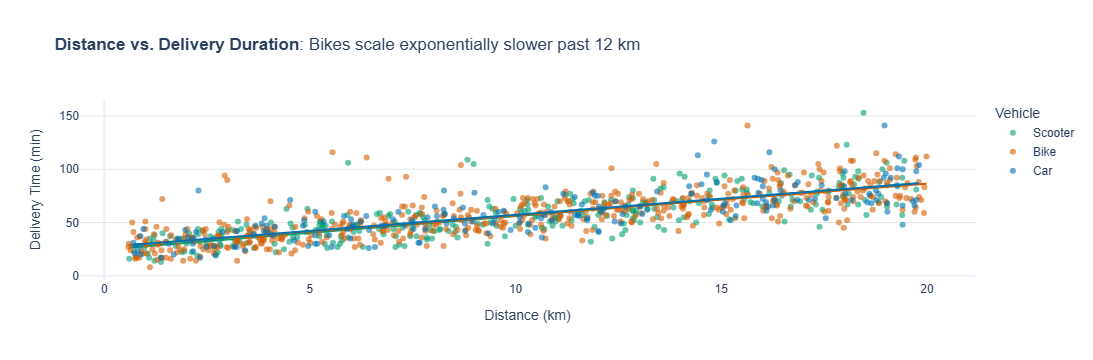

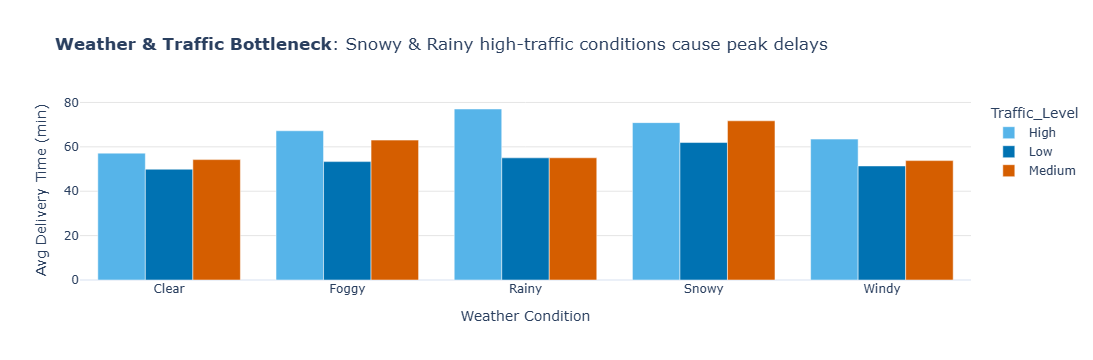

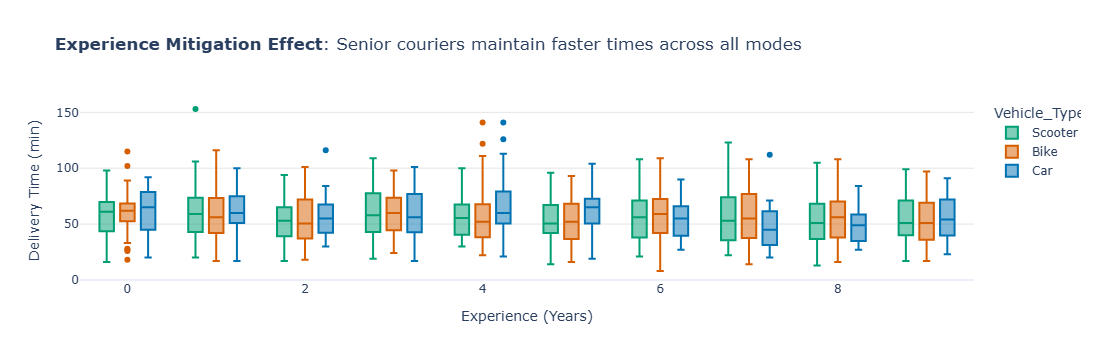

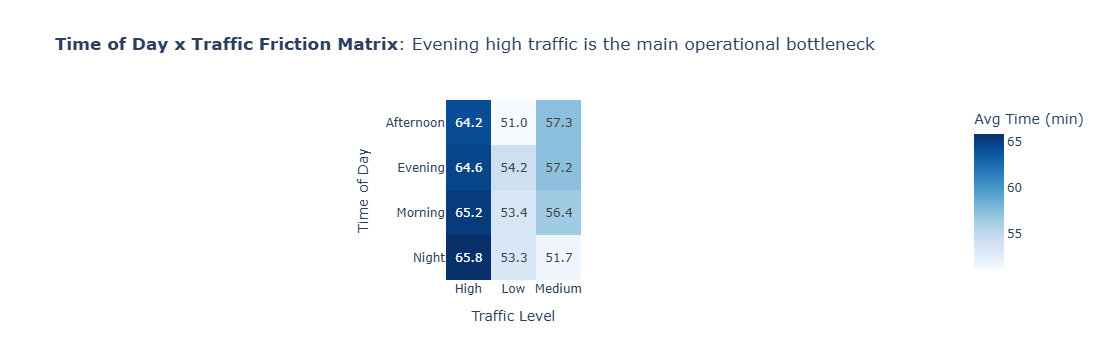

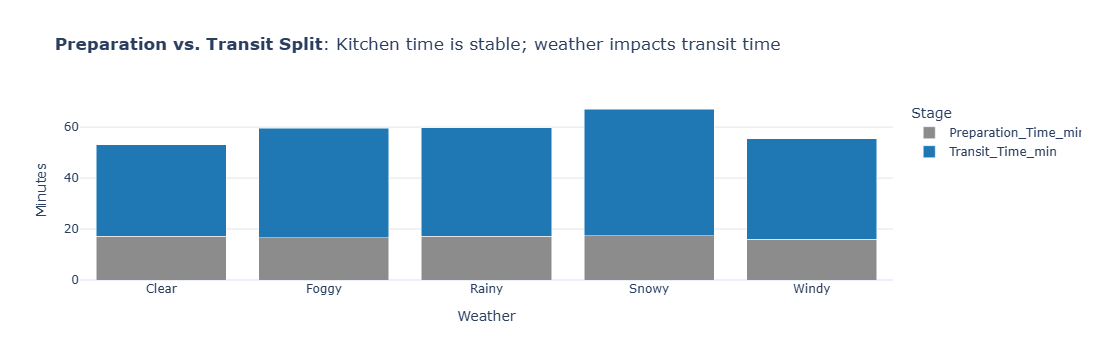

C:\Users\Manohar\AppData\Local\Temp\ipykernel_4808\1393033383.py:110: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



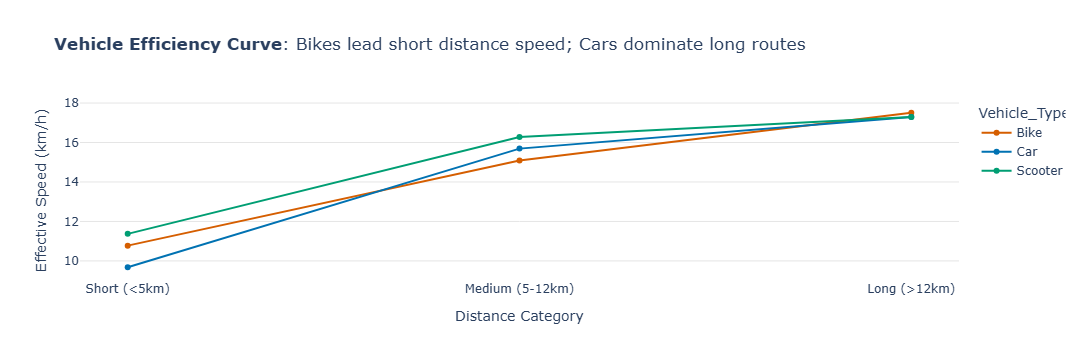

C:\Users\Manohar\AppData\Local\Temp\ipykernel_4808\1393033383.py:124: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



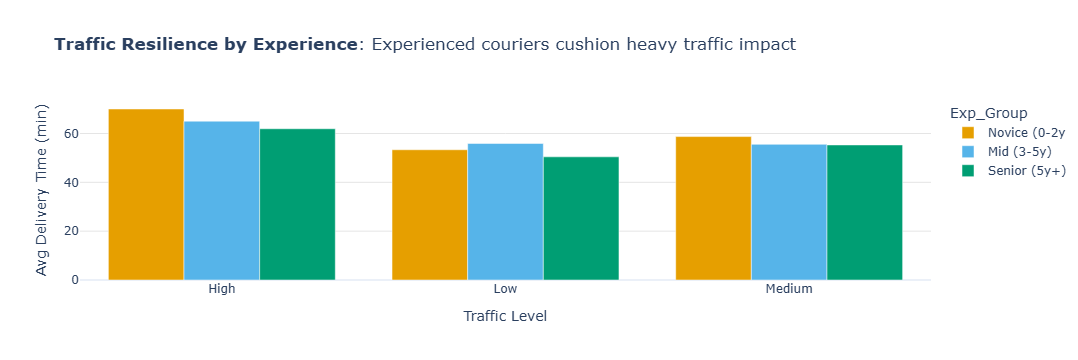

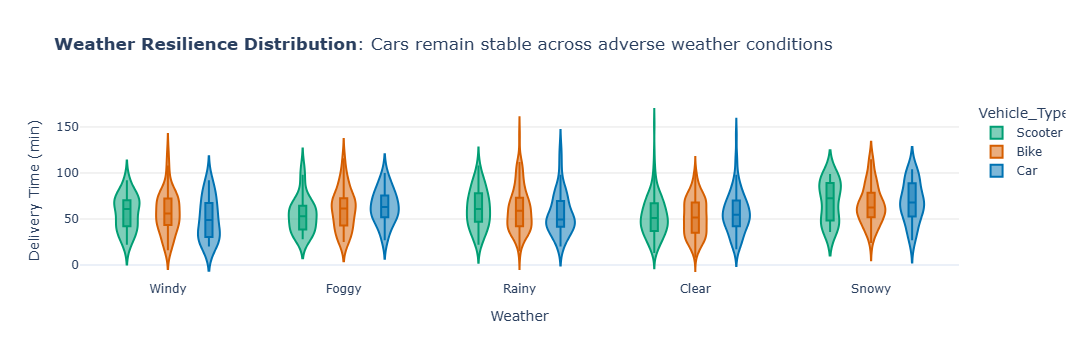

TypeError: strip() got an unexpected keyword argument 'stripegroup'

In [6]:
# ==========================================
# 0. IMPORTS & SETUP
# ==========================================
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as io
import plotly.io as pio

# Set Plotly default template to clean white background
pio.templates.default = "plotly_white"

# CVD-Safe Color Palette Definition (Okabe-Ito inspired / High contrast)
PRIMARY_BLUE = "#1F77B4"
HIGHLIGHT_ORANGE = "#FF7F0E"
MUTED_GREY = "#8C8C8C"
LIGHT_GREY = "#E5E5E5"
PALETTE_CVD = ["#0072B2", "#D55E00", "#009E73", "#F0E442", "#56B4E9"]

# ==========================================
# 1. DATA LOADING & CLEANING (EDA)
# ==========================================
# Absolute path to your dataset file
file_path = r"C:\Users\Manohar\Desktop\data-viz\dataviz-exercises\final_project\data\Food_Delivery_Times.csv"

df = pd.read_csv(file_path)

# Clean missing values using median / mode imputation
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])
df['Traffic_Level'] = df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0])
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

# Feature Engineering
df['Speed_kmh'] = df['Distance_km'] / ((df['Delivery_Time_min'] - df['Preparation_Time_min']) / 60)
df['Distance_Category'] = pd.cut(df['Distance_km'], bins=[0, 5, 12, 25], labels=['Short (<5km)', 'Medium (5-12km)', 'Long (>12km)'])

print("Data Cleaning Complete. Dataset Shape:", df.shape)

# ==========================================
# 2. THE 10 ANALYTICAL QUESTIONS & PLOTLY VISUALS
# ==========================================

# ------------------------------------------
# Q1: How does delivery duration scale with distance across different vehicle types?
# ------------------------------------------
fig1 = px.scatter(
    df, x='Distance_km', y='Delivery_Time_min', color='Vehicle_Type',
    trendline='ols', opacity=0.6,
    color_discrete_map={'Car': '#0072B2', 'Scooter': '#009E73', 'Bike': '#D55E00'},
    title="<b>Distance vs. Delivery Duration</b>: Bikes scale exponentially slower past 12 km",
    labels={'Distance_km': 'Distance (km)', 'Delivery_Time_min': 'Delivery Time (min)', 'Vehicle_Type': 'Vehicle'}
)
fig1.update_layout(xaxis=dict(showgrid=False), yaxis=dict(showgrid=True, gridcolor=LIGHT_GREY), font_family="Arial")
fig1.show()

# ------------------------------------------
# Q2: How do weather conditions compound delivery delays under varying traffic levels?
# ------------------------------------------
df_q2 = df.groupby(['Weather', 'Traffic_Level'])['Delivery_Time_min'].mean().reset_index()
fig2 = px.bar(
    df_q2, x='Weather', y='Delivery_Time_min', color='Traffic_Level', barmode='group',
    color_discrete_sequence=['#56B4E9', '#0072B2', '#D55E00'],
    title="<b>Weather & Traffic Bottleneck</b>: Snowy & Rainy high-traffic conditions cause peak delays",
    labels={'Delivery_Time_min': 'Avg Delivery Time (min)', 'Weather': 'Weather Condition'}
)
fig2.update_layout(xaxis=dict(showgrid=False), yaxis=dict(showgrid=True, gridcolor=LIGHT_GREY))
fig2.show()

# ------------------------------------------
# Q3: Does courier experience buffer against delivery delays across vehicle types?
# ------------------------------------------
fig3 = px.box(
    df, x='Courier_Experience_yrs', y='Delivery_Time_min', color='Vehicle_Type',
    color_discrete_map={'Car': '#0072B2', 'Scooter': '#009E73', 'Bike': '#D55E00'},
    title="<b>Experience Mitigation Effect</b>: Senior couriers maintain faster times across all modes",
    labels={'Courier_Experience_yrs': 'Experience (Years)', 'Delivery_Time_min': 'Delivery Time (min)'}
)
fig3.update_layout(xaxis=dict(showgrid=False), yaxis=dict(showgrid=True, gridcolor=LIGHT_GREY))
fig3.show()

# ------------------------------------------
# Q4: How do peak times of day interact with traffic levels to impact delivery duration?
# ------------------------------------------
q4_data = df.pivot_table(index='Time_of_Day', columns='Traffic_Level', values='Delivery_Time_min', aggfunc='mean')
fig4 = px.imshow(
    q4_data, text_auto=".1f", color_continuous_scale="Blues",
    title="<b>Time of Day x Traffic Friction Matrix</b>: Evening high traffic is the main operational bottleneck",
    labels=dict(x="Traffic Level", y="Time of Day", color="Avg Time (min)")
)
fig4.show()

# ------------------------------------------
# Q5: What is the relative contribution of kitchen preparation time versus transit weather delays?
# ------------------------------------------
df_q5 = df.groupby('Weather')[['Preparation_Time_min', 'Delivery_Time_min']].mean().reset_index()
df_q5['Transit_Time_min'] = df_q5['Delivery_Time_min'] - df_q5['Preparation_Time_min']
fig5 = px.bar(
    df_q5, x='Weather', y=['Preparation_Time_min', 'Transit_Time_min'],
    title="<b>Preparation vs. Transit Split</b>: Kitchen time is stable; weather impacts transit time",
    color_discrete_map={'Preparation_Time_min': MUTED_GREY, 'Transit_Time_min': PRIMARY_BLUE},
    labels={'value': 'Minutes', 'variable': 'Stage'}
)
fig5.update_layout(barmode='stack', xaxis=dict(showgrid=False), yaxis=dict(showgrid=True, gridcolor=LIGHT_GREY))
fig5.show()

# ------------------------------------------
# Q6: Which vehicle type maintains optimal average speed across distance categories?
# ------------------------------------------
df_q6 = df.groupby(['Distance_Category', 'Vehicle_Type'])['Speed_kmh'].mean().reset_index()
fig6 = px.line(
    df_q6, x='Distance_Category', y='Speed_kmh', color='Vehicle_Type', markers=True,
    color_discrete_map={'Car': '#0072B2', 'Scooter': '#009E73', 'Bike': '#D55E00'},
    title="<b>Vehicle Efficiency Curve</b>: Bikes lead short distance speed; Cars dominate long routes",
    labels={'Speed_kmh': 'Effective Speed (km/h)', 'Distance_Category': 'Distance Category'}
)
fig6.update_layout(xaxis=dict(showgrid=False), yaxis=dict(showgrid=True, gridcolor=LIGHT_GREY))
fig6.show()

# ------------------------------------------
# Q7: Does high courier experience insulate against heavy traffic disruptions?
# ------------------------------------------
df['Exp_Group'] = pd.cut(df['Courier_Experience_yrs'], bins=[-1, 2, 5, 10], labels=['Novice (0-2y)', 'Mid (3-5y)', 'Senior (5y+)'])
df_q7 = df.groupby(['Traffic_Level', 'Exp_Group'])['Delivery_Time_min'].mean().reset_index()
fig7 = px.bar(
    df_q7, x='Traffic_Level', y='Delivery_Time_min', color='Exp_Group', barmode='group',
    color_discrete_sequence=['#E69F00', '#56B4E9', '#009E73'],
    title="<b>Traffic Resilience by Experience</b>: Experienced couriers cushion heavy traffic impact",
    labels={'Delivery_Time_min': 'Avg Delivery Time (min)', 'Traffic_Level': 'Traffic Level'}
)
fig7.update_layout(xaxis=dict(showgrid=False), yaxis=dict(showgrid=True, gridcolor=LIGHT_GREY))
fig7.show()

# ------------------------------------------
# Q8: Which vehicle type demonstrates highest resilience against extreme weather?
# ------------------------------------------
fig8 = px.violin(
    df, x='Weather', y='Delivery_Time_min', color='Vehicle_Type', box=True, points=False,
    color_discrete_map={'Car': '#0072B2', 'Scooter': '#009E73', 'Bike': '#D55E00'},
    title="<b>Weather Resilience Distribution</b>: Cars remain stable across adverse weather conditions",
    labels={'Delivery_Time_min': 'Delivery Time (min)'}
)
fig8.update_layout(xaxis=dict(showgrid=False), yaxis=dict(showgrid=True, gridcolor=LIGHT_GREY))
fig8.show()

# ------------------------------------------
# Q9: How consistent (variable) are delivery times across times of day by vehicle?
# ------------------------------------------
fig9 = px.strip(
    df, x='Time_of_Day', y='Delivery_Time_min', color='Vehicle_Type', stripegroup='Vehicle_Type', jitter=0.3,
    color_discrete_map={'Car': '#0072B2', 'Scooter': '#009E73', 'Bike': '#D55E00'},
    title="<b>Delivery Predictability</b>: Night slots offer high consistency across all vehicle types",
    labels={'Delivery_Time_min': 'Delivery Duration (min)'}
)
fig9.update_layout(xaxis=dict(showgrid=False), yaxis=dict(showgrid=True, gridcolor=LIGHT_GREY))
fig9.show()

# ------------------------------------------
# Q10: Multi-Factor Bottleneck Analysis: Distance x Prep Time x Traffic interaction
# ------------------------------------------
fig10 = px.scatter(
    df, x='Preparation_Time_min', y='Delivery_Time_min', size='Distance_km', color='Traffic_Level',
    hover_data=['Vehicle_Type', 'Weather'],
    color_discrete_map={'Low': '#009E73', 'Medium': '#E69F00', 'High': '#D55E00'},
    title="<b>Multi-Factor Friction Analysis</b>: High prep combined with high traffic maximizes latency",
    labels={'Preparation_Time_min': 'Prep Time (min)', 'Delivery_Time_min': 'Total Delivery Time (min)'}
)
fig10.update_layout(xaxis=dict(showgrid=False), yaxis=dict(showgrid=True, gridcolor=LIGHT_GREY))
fig10.show()